# Examples of using the icechunks

In [1]:
# Required packages; need earthaccess > 18
!pip install -qU icechunk earthaccess cartopy

In [2]:
# need v 18
import earthaccess
earthaccess.__version__

'0.18.0'

## Reading of our icechunk

We need to pass in EDL tokens to be able to open our store. Your compute needs to be in AWS us-west-2 (e.g. CryoCloud) for the inregion icechunks.

In [4]:
%%time
import earthaccess
import icechunk as ic
import xarray as xr

url = "https://data.source.coop/fish-pace/pace-oci/inregion/PACE_OCI_L3M_CHL"

storage = ic.http_storage(url)

auth = earthaccess.login()
s3_credentials = auth.get_s3_credentials(daac="OBDAAC")

url_prefix = "s3://ob-cumulus-prod-public/"

virtual_creds = ic.credentials.containers_credentials({
    url_prefix: ic.credentials.s3_credentials(
        access_key_id=s3_credentials["accessKeyId"],
        secret_access_key=s3_credentials["secretAccessKey"],
        session_token=s3_credentials["sessionToken"],
    )
})

repo = ic.Repository.open(
    storage,
    authorize_virtual_chunk_access=virtual_creds,
)

store = repo.readonly_session("main").store

ds512 = xr.open_zarr(
    store,
    consolidated=False,
    group="daily/0p1deg/chunks_512",
)

ds16 = xr.open_zarr(
    store,
    consolidated=False,
    group="daily/0p1deg/chunks_16",
)

CPU times: user 406 ms, sys: 36.2 ms, total: 442 ms
Wall time: 2.47 s


In [5]:
# Concat the groups
ds = xr.concat(
    [ds512, ds16],
    dim="time",
    coords="minimal",
    compat="override",
    combine_attrs="override",
).sortby("time")

## Make a plot


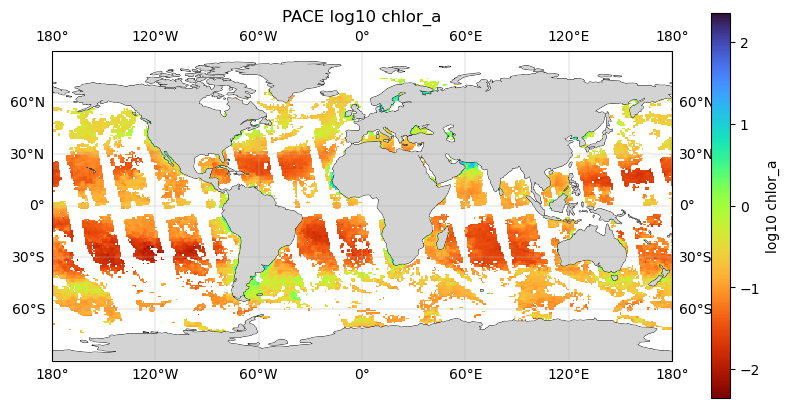

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

da_small = ds["chlor_a"].isel(time=10).coarsen(
    lat=8,
    lon=8,
    boundary="trim",
).mean().compute()

log_chl = np.log10(da_small.where(da_small > 0))

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

log_chl.plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap="turbo_r",
    cbar_kwargs={"label": "log10 chlor_a"},
)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
ax.set_global()
ax.gridlines(draw_labels=True, linewidth=0.3)

plt.title("PACE log10 chlor_a")
plt.show()

## Time series at a point

Box is in the North Arabian Sea.

CPU times: user 12.8 s, sys: 1.03 s, total: 13.8 s
Wall time: 23.7 s


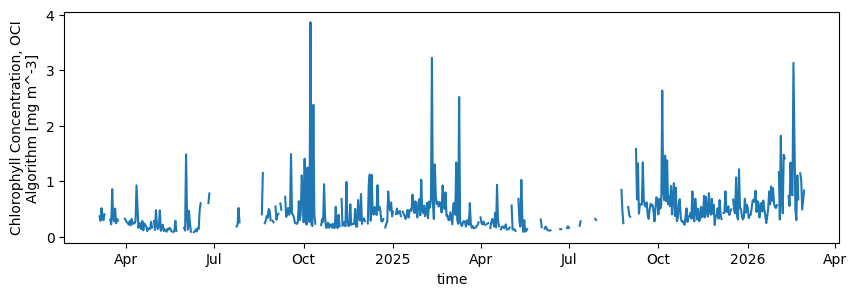

In [7]:
%%time
bbox = ds["chlor_a"].sel(
    lon=slice(65, 75),
    lat=slice(20, 10),
)

ts = bbox.mean(("lat", "lon")).compute()

ts.plot(figsize=(10, 3));

## Monthly averages

CPU times: user 15.2 s, sys: 1.19 s, total: 16.4 s
Wall time: 19.7 s


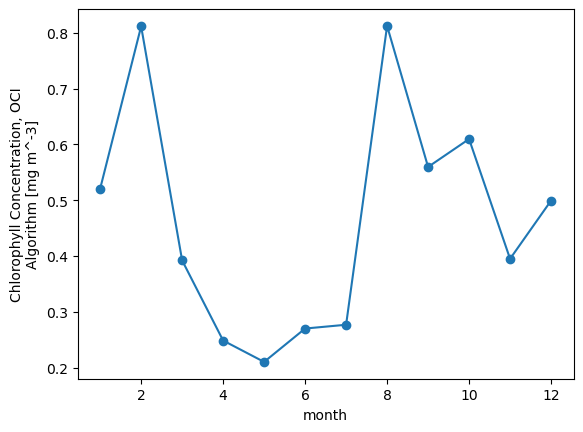

In [8]:
%%time
clim = (
    ds["chlor_a"]
    .sel(lon=slice(65, 75), lat=slice(20, 10))
    .mean(("lat", "lon"))
    .groupby("time.month")
    .mean()
    .compute()
)

clim.plot(marker="o");